# Calculated 3RRS LQR and Inverse Kinematics Notebook

โน้ตบุ๊กนี้สร้างแบบจำลองควบคุมของระบบ 3RRS ball-and-plate จากพารามิเตอร์ที่คุณให้มา แล้วประมาณค่าที่ยังขาดให้สอดคล้องกับขนาดจริงของกลไก

เป้าหมายของโน้ตบุ๊กนี้มี 4 ส่วน
1. คำนวณพารามิเตอร์ที่อนุมานได้จากข้อมูลจริง เช่น moment of inertia ของลูกบอล, rolling factor, และ time constant ของ servo
2. สร้าง control-level kinematics ของแท่นในรูป $z = Jp$
3. สร้าง exact inverse kinematics ของขา 2-link ทีละขา และ linearize ให้ได้ actuator gain สำหรับ inner loop
4. สร้าง state-space และคำนวณ LQR สำหรับ outer loop พร้อม simulation ต้นแบบ

## ข้อมูลที่ใช้จริงจากโจทย์
- ลูกบอล: มวล $m_b = 2.7$ g, เส้นผ่านศูนย์กลาง $40$ mm
- แท่น: เส้นผ่านศูนย์กลาง $300$ mm, หนา $10$ mm, มวล $m_p = 756.34$ g
- โมเมนต์ความเฉื่อยของแท่น: $I_x = 4.261 	imes 10^{-3}$ และ $I_z = 8.509 	imes 10^{-3}athrm{kgdot m^2}$
- กลไกแต่ละขา: $L_1 = 100$ mm, $L_2 = 148.2$ mm
- Servo: Hiwonder HX-30HM, no-load speed $0.19$ s ต่อ $60^irc$

## สมมติฐานเพิ่มเพื่อให้คำนวณได้ครบ
- ลูกบอลถูกมองเป็น thin hollow sphere เพราะมวล 2.7 g และเส้นผ่านศูนย์กลาง 40 mm ใกล้เคียงลูกปิงปอง
- จุดยึดบนแท่นทั้ง 3 จุดอยู่บนวงกลมรัศมี $R_p = 0.12$ m เพื่อให้ยังอยู่ในขอบแท่นรัศมี 0.15 m อย่างมี margin
- Servo base อยู่บนวงกลมรัศมี $R_b = 0.18$ m ซึ่งมากกว่ารัศมีแท่นเล็กน้อยและสอดคล้องกับความยาวลิงก์ที่ให้มา
- ความสูง nominal ของแท่นใช้ $h_0 = 0.20$ m วัดจากระนาบฐานของ servo ถึงระนาบจุดยึดบนแท่น
- แบบจำลองควบคุมใช้ small-angle approximation สำหรับ outer loop
- dynamics ของ actuator ใช้ first-order approximation จากข้อมูลความเร็ว no-load ของ servo
- แรงต้านของลูกบนแท่นใช้ค่าประมาณเชิงเส้น $b = 0.003athrm{Ndot s/m}$ เพื่อให้เกิด damping ระดับพอเหมาะสำหรับ prototype simulation

โน้ตบุ๊กนี้ตั้งใจให้ใช้เป็นเอกสารเสนอแนวทางกับอาจารย์ ไม่ใช่ final identified model ของเครื่องจริง

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_are, eigvals

np.set_printoptions(precision=6, suppress=True)

## 1. กำหนดพารามิเตอร์จริงและค่าที่ประมาณเพิ่ม

ใน cell ถัดไป เราจะกำหนดพารามิเตอร์ทั้งหมดให้อยู่รวมกันในที่เดียว เพื่อให้ง่ายต่อการแก้ภายหลัง

สิ่งสำคัญคือเราจะแยกเป็น 3 กลุ่ม
- physical parameters ของลูกบอลและแท่น
- geometry ของกลไก 3RRS
- control parameters ที่ใช้สำหรับการ linearize และออกแบบ LQR

ค่าของลูกบอลจะถูกใช้คำนวณ rolling factor

$$
I_b = \frac{2}{3} m_b r_b^2, \qquad
k_r = \frac{1}{1 + \dfrac{I_b}{m_b r_b^2}}
$$

และจากความเร็ว no-load ของ servo

$$
\omega_{\mathrm{nl}} = \frac{60^\circ}{0.19\,\mathrm{s}}
$$

เราจะประมาณ actuator time constant แบบหยาบด้วย

$$
T_a \approx \frac{1}{\omega_{\mathrm{nl}}}
$$

ซึ่งไม่ใช่ model จริงของ servo แต่เหมาะสำหรับ conceptual control design

In [ ]:
# Ball parameters
mb = 0.0027                     # kg
ball_diameter = 0.04           # m
ball_radius = ball_diameter / 2
Ib = (2.0 / 3.0) * mb * ball_radius**2
kr = 1.0 / (1.0 + Ib / (mb * ball_radius**2))

# Plate parameters
mp = 0.75634                   # kg
plate_diameter = 0.30          # m
plate_radius = plate_diameter / 2
plate_thickness = 0.01         # m
Ix = 4.261e-3                  # kg.m^2
Iz = 8.509e-3                  # kg.m^2

# 3RRS mechanism geometry
L1 = 0.10                      # m
L2 = 0.1482                    # m
Rp = 0.12                      # m, platform anchor radius
Rb = 0.18                      # m, base servo radius
h0 = 0.20                      # m, nominal platform height
base_height = 0.0              # m
psi = np.array([0.0, 2.0 * np.pi / 3.0, 4.0 * np.pi / 3.0])

# Servo and damping approximation
servo_speed_rad_s = np.deg2rad(60.0) / 0.19
Ta = 1.0 / servo_speed_rad_s
b = 0.003                      # N.s/m
g = 9.81
tilt_limit = np.deg2rad(6.0)

print(f'Ball inertia Ib = {Ib:.6e} kg.m^2')
print(f'Rolling factor kr = {kr:.6f}')
print(f'Plate inertia Ix = {Ix:.6e} kg.m^2')
print(f'Plate inertia Iz = {Iz:.6e} kg.m^2')
print(f'Estimated servo time constant Ta = {Ta:.6f} s')
print(f'Damping ratio term b/m = {b / mb:.6f} 1/s')

Ball inertia Ib = 7.200000e-07 kg.m^2
Rolling factor kr = 0.600000
Plate inertia Ix = 4.261000e-03 kg.m^2
Plate inertia Iz = 8.509000e-03 kg.m^2
Estimated servo time constant Ta = 0.181437 s
Damping ratio term b/m = 1.111111 1/s


## 2. Control-level platform kinematics

ในระดับ outer loop เราไม่จำเป็นต้องแก้ exact closed-form kinematics ของ parallel manipulator ทั้งระบบทุกครั้ง
สิ่งที่ใช้สำหรับควบคุมได้ง่ายกว่า คือเขียนความสัมพันธ์ระหว่าง pose ของแท่นกับความสูงของจุดรองรับทั้ง 3 จุด

กำหนด

$$
p = \begin{bmatrix} \phi \\ \theta \\ h \end{bmatrix}
$$

และตำแหน่งจุดยึดบนแท่นอยู่ที่

$$
x_i = R_p \cos \psi_i, \qquad y_i = R_p \sin \psi_i
$$

สำหรับมุมเอียงเล็ก ความสูงของแต่ละจุดคือ

$$
z_i = y_i \phi - x_i \theta + h
$$

จึงเขียนรวมได้เป็น

$$
z = Jp
$$

ซึ่งใช้ได้ทั้งสำหรับ inverse kinematics แบบเชิงเส้นและ forward kinematics แบบเชิงเส้น

In [3]:
x_anchor = Rp * np.cos(psi)
y_anchor = Rp * np.sin(psi)
J = np.vstack([y_anchor, -x_anchor, np.ones(3)]).T
Jinv = np.linalg.inv(J)

print('J =')
print(J)
print('\nJinv =')
print(Jinv)

J =
[[ 0.       -0.12      1.      ]
 [ 0.103923  0.06      1.      ]
 [-0.103923  0.06      1.      ]]

Jinv =
[[-0.        4.811252 -4.811252]
 [-5.555556  2.777778  2.777778]
 [ 0.333333  0.333333  0.333333]]


## 3. Exact inverse kinematics ของขา 2-link

ในระดับกลไกจริง แต่ละขาจะถูกมองเป็น planar 2-link chain ที่เคลื่อนในระนาบรัศมีของตัวเอง

สำหรับขาที่ $i$
- จุดฐานของ servo อยู่ที่ $B_i$
- จุดยึดบนแท่นอยู่ที่ $P_i$
- เมื่อแปลงเข้าสู่ระนาบของขา จะเหลือพิกัดเป้าหมาย $(x_i, z_i)$

จากนั้นใช้สมการ 2-link IK มาตรฐาน

$$
\cos q_{2,i} = \frac{x_i^2 + z_i^2 - L_1^2 - L_2^2}{2L_1L_2}
$$

$$
q_{2,i} = \arccos(\cos q_{2,i})
$$

$$
q_{1,i} = \operatorname{atan2}(z_i, x_i) - \operatorname{atan2}(L_2 \sin q_{2,i}, L_1 + L_2 \cos q_{2,i})
$$

เราจะคำนวณ 2 อย่างใน cell ถัดไป
1. neutral pose exact IK ของทั้ง 3 ขา
2. linearized actuator gain $k_{act}$ โดยประมาณจาก slope ใกล้จุดทำงาน

สำหรับ $k_{act}$ เราไม่ใช้ $\partial z / \partial q_1$ แบบถือ $q_2$ คงที่ เพราะจริง ๆ แล้ว $q_2$ เปลี่ยนตาม constraint ของกลไก
ดังนั้นเราจะหาค่าเชิงตัวเลขจากการ perturb ความสูงเล็กน้อยรอบ nominal pose แล้วดูว่า motor angle เปลี่ยนไปเท่าไร

In [4]:
def rotation_matrix_z(angle):
    c = math.cos(angle)
    s = math.sin(angle)
    return np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])


def base_point(index):
    angle = psi[index]
    return np.array([Rb * math.cos(angle), Rb * math.sin(angle), base_height])


def platform_anchor_world(phi, theta, h, index):
    x_local = Rp * math.cos(psi[index])
    y_local = Rp * math.sin(psi[index])
    z_local = 0.0
    anchor_local = np.array([x_local, y_local, z_local])

    # Exact rotation is kept here although outer-loop control uses the small-angle J matrix
    cx, sx = math.cos(phi), math.sin(phi)
    cy, sy = math.cos(theta), math.sin(theta)
    Rx = np.array([[1.0, 0.0, 0.0], [0.0, cx, -sx], [0.0, sx, cx]])
    Ry = np.array([[cy, 0.0, sy], [0.0, 1.0, 0.0], [-sy, 0.0, cy]])
    R = Ry @ Rx
    return np.array([0.0, 0.0, h]) + R @ anchor_local


def world_to_leg_plane(target_world, index):
    leg_yaw = psi[index] + math.pi
    rel_world = np.asarray(target_world) - base_point(index)
    return rotation_matrix_z(-leg_yaw) @ rel_world


def solve_leg_ik(phi, theta, h, index, elbow_sign=1.0):
    target_world = platform_anchor_world(phi, theta, h, index)
    rel_leg = world_to_leg_plane(target_world, index)
    x_local = rel_leg[0]
    z_local = rel_leg[2]
    cos_q2 = (x_local**2 + z_local**2 - L1**2 - L2**2) / (2.0 * L1 * L2)
    cos_q2 = float(np.clip(cos_q2, -1.0, 1.0))
    q2 = elbow_sign * math.acos(cos_q2)
    k1 = L1 + L2 * math.cos(q2)
    k2 = L2 * math.sin(q2)
    q1 = math.atan2(z_local, x_local) - math.atan2(k2, k1)
    return q1, q2, rel_leg


def actuator_gain_from_numerical_linearization(index=0, dz=1e-4):
    q1_minus, _, _ = solve_leg_ik(0.0, 0.0, h0 - dz, index)
    q1_plus, _, _ = solve_leg_ik(0.0, 0.0, h0 + dz, index)
    dq_dz = (q1_plus - q1_minus) / (2.0 * dz)
    return 1.0 / dq_dz


neutral_results = []
for leg_index in range(3):
    q1, q2, rel = solve_leg_ik(0.0, 0.0, h0, leg_index)
    neutral_results.append((q1, q2, rel))

k_act_values = [actuator_gain_from_numerical_linearization(i) for i in range(3)]
k_act = float(np.mean(k_act_values))

for leg_index, (q1, q2, rel) in enumerate(neutral_results, start=1):
    print(f'Leg {leg_index}: rel = {rel}, q1 = {q1:.6f} rad, q2 = {q2:.6f} rad')

print('k_act per leg (m/rad) =', np.array(k_act_values))
print(f'Average k_act = {k_act:.6f} m/rad')

Leg 1: rel = [0.06 0.   0.2 ], q1 = 0.568115 rad, q2 = 1.167336 rad
Leg 2: rel = [0.06 0.   0.2 ], q1 = 0.568115 rad, q2 = 1.167336 rad
Leg 3: rel = [0.06 0.   0.2 ], q1 = 0.568115 rad, q2 = 1.167336 rad
k_act per leg (m/rad) = [0.093232 0.093232 0.093232]
Average k_act = 0.093232 m/rad


## 4. Outer-loop dynamics ของลูกบอลและ state-space สำหรับ LQR

เมื่อเลือกให้ inner loop ของ actuator ทำหน้าที่สร้างมุมเอียงของแท่นตาม reference เร็วกว่าการเคลื่อนของลูกบอล
เราสามารถออกแบบ outer loop ต่อแกนได้จากสถานะ

$$
x_{axis} = \begin{bmatrix} e \\ \dot{e} \\ \alpha \end{bmatrix}
$$

โดยที่
- $e$ คือ position error ของลูกบอลในแกนนั้น
- $\dot{e}$ คือความเร็วของลูกบอล
- $\alpha$ คือมุมเอียงจริงของแท่นในแกนนั้น

สมการเชิงเส้นที่ใช้คือ

$$
\ddot{e} = -\frac{b}{m_b} \dot{e} + k_r g \alpha
$$

และ actuator dynamics

$$
\dot{\alpha} = -\frac{1}{T_a} \alpha + \frac{1}{T_a} u
$$

ดังนั้นจะได้

$$
\dot{x}_{axis} = A_{axis} x_{axis} + B_{axis} u
$$

เราเลือก $Q$ และ $R$ ด้วยแนวคิดแบบ Bryson's rule
- position error ที่ยอมได้ประมาณ 2 cm
- velocity error ที่ยอมได้ประมาณ 0.15 m/s
- platform tilt ที่ยอมได้ประมาณ 5 deg
- command tilt ที่ยอมได้ประมาณ 6 deg

แล้วแก้ continuous-time Riccati equation เพื่อหา gain $K$

In [5]:
A_axis = np.array([
    [0.0, 1.0, 0.0],
    [0.0, -(b / mb), kr * g],
    [0.0, 0.0, -(1.0 / Ta)],
])
B_axis = np.array([[0.0], [0.0], [1.0 / Ta]])

Q_axis = np.diag([
    1.0 / (0.02**2),
    1.0 / (0.15**2),
    1.0 / (np.deg2rad(5.0)**2),
])
R_axis = np.array([[1.0 / (np.deg2rad(6.0)**2)]])

P_axis = solve_continuous_are(A_axis, B_axis, Q_axis, R_axis)
K_axis = np.linalg.inv(R_axis) @ B_axis.T @ P_axis
cl_poles = eigvals(A_axis - B_axis @ K_axis)

print('A_axis =')
print(A_axis)
print('\nB_axis =')
print(B_axis)
print('\nQ_axis =')
print(Q_axis)
print('\nR_axis =')
print(R_axis)
print('\nK_axis =')
print(K_axis)
print('\nClosed-loop poles =')
print(cl_poles)

A_axis =
[[ 0.        1.        0.      ]
 [ 0.       -1.111111  5.886   ]
 [ 0.        0.       -5.511566]]

B_axis =
[[0.      ]
 [0.      ]
 [5.511566]]

Q_axis =
[[2500.          0.          0.      ]
 [   0.         44.444444    0.      ]
 [   0.          0.        131.312254]]

R_axis =
[[91.189065]]

K_axis =
[[5.235988 1.853465 1.529578]]

Closed-loop poles =
[-3.268967+3.043361j -3.268967-3.043361j -8.515111+0.j      ]


## 5. การแปลง pose command ไปเป็น actuator command

เพื่อให้เห็นภาพการใช้งาน เราจะทดลองสั่งแท่นให้เอียง
- $\phi = 3^\circ$
- $\theta = -2^\circ$
- $h = h_0$

จากนั้นคำนวณ 2 แบบ
1. control-level inverse kinematics: ใช้ $z_{ref} = J p_{ref}$ แล้วแปลงต่อเป็น $q_{ref} \approx z_{ref}/k_{act}$
2. exact leg IK: แก้ $q_1, q_2$ ของแต่ละขาตรงจาก geometry

เมื่อใช้ทั้งสองแบบร่วมกัน สามารถอธิบายได้ว่า
- ชั้นควบคุมใช้ linearized model เพื่อออกแบบ LQR
- ชั้นกลไกใช้ exact IK เพื่อ map ไปยังมุมจริงของขา

In [6]:
phi_cmd = np.deg2rad(3.0)
theta_cmd = np.deg2rad(-2.0)
p_ref = np.array([phi_cmd, theta_cmd, h0])
z_ref = J @ p_ref
q_ref_linear = z_ref / k_act
pose_recovered = Jinv @ z_ref

exact_leg_commands = []
for leg_index in range(3):
    q1, q2, rel = solve_leg_ik(phi_cmd, theta_cmd, h0, leg_index)
    exact_leg_commands.append((q1, q2, rel))

print('Requested pose p_ref = [phi, theta, h] =', p_ref)
print('Control-level support heights z_ref =', z_ref)
print('Linearized motor commands q_ref_linear =', q_ref_linear)
print('Recovered pose from Jinv =', pose_recovered)
print()
for leg_index, (q1, q2, rel) in enumerate(exact_leg_commands, start=1):
    print(f'Leg {leg_index}: rel = {rel}, q1 = {q1:.6f} rad, q2 = {q2:.6f} rad')

Requested pose p_ref = [phi, theta, h] = [ 0.05236  -0.034907  0.2     ]
Control-level support heights z_ref = [0.204189 0.203347 0.192464]
Linearized motor commands q_ref_linear = [2.190122 2.181093 2.064365]
Recovered pose from Jinv = [ 0.05236  -0.034907  0.2     ]

Leg 1: rel = [0.060073 0.       0.204188], q1 = 0.613617 rad, q2 = 1.104021 rad
Leg 2: rel = [ 0.060047 -0.000204  0.203342], q1 = 0.604319 rad, q2 = 1.117128 rad
Leg 3: rel = [ 0.060237 -0.000125  0.19247 ], q1 = 0.488729 rad, q2 = 1.272532 rad


## 6. Simulation ต้นแบบของระบบควบคุมแบบรักษาลูกบอลให้อยู่กลางแผ่น

cell นี้เปลี่ยนจากกรณี path tracking ไปเป็นกรณี balance ที่เข้าใจง่ายกว่าในการนำเสนอ คือ
- วางลูกบอลเริ่มต้นให้เยื้องจากศูนย์กลางแผ่น
- ตั้ง reference เป็นจุดศูนย์กลางตลอดเวลา
- ให้ LQR สั่งมุมเอียงของแท่นเพื่อดึงลูกบอลกลับมาที่ $(0,0)$

กราฟที่จะแสดงมีความหมายดังนี้
1. กราฟตำแหน่งลูกบอลแกน $x$ และ $y$ เทียบกับเวลา: ใช้ดูว่าลูกบอลค่อย ๆ กลับเข้าสู่ศูนย์กลางหรือไม่
2. กราฟมุมเอียงของแท่น $\phi$ และ $\theta$ เทียบกับค่าอ้างอิง: ใช้ดูว่า controller สั่งให้แท่นเอียงไปทางไหน และมุมจริงตามคำสั่งได้ดีแค่ไหน
3. กราฟระยะห่างจากศูนย์กลาง $r = \sqrt{x^2 + y^2}$: เป็นกราฟสำคัญที่สุดสำหรับอธิบายการ balance เพราะถ้า controller ดี ค่า $r$ ต้องลดลงเข้าใกล้ศูนย์
4. กราฟวิถีการเคลื่อนที่บนระนาบ $x$-$y$: ใช้ดูภาพรวมว่าลูกบอลเคลื่อนจากจุดเริ่มต้นกลับเข้าสู่ศูนย์กลางอย่างไร

ถ้าในผลลัพธ์เห็นว่า
- $x$ และ $y$ ลดลงเข้าใกล้ศูนย์
- มุมเอียงของแท่นไม่แกว่งรุนแรงเกินไป
- ระยะ $r$ ลดลงต่อเนื่อง
ก็สามารถสรุปได้ว่า controller สามารถรักษาสมดุลลูกบอลบนแผ่นได้ในระดับต้นแบบของแบบจำลองนี้

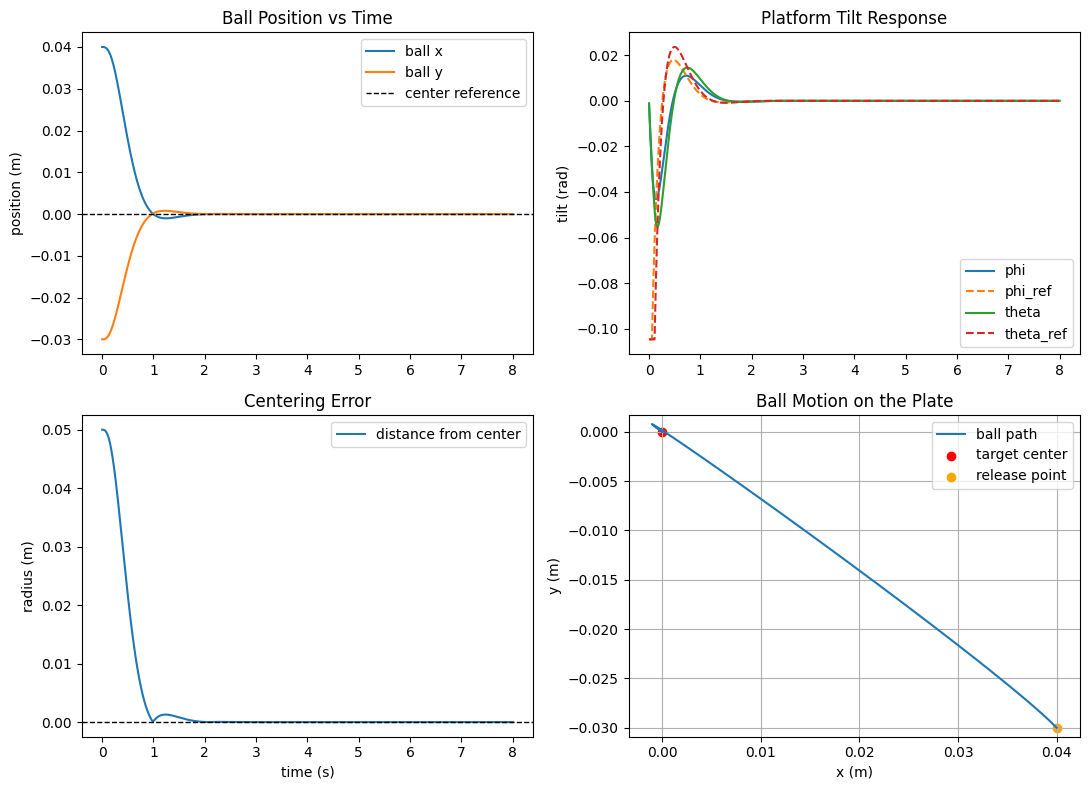

Initial offset from center = 0.050000 m
Final offset from center = 0.000000 m
Peak offset from center = 0.050000 m
Settling time within 5 mm band = 0.782000 s


In [8]:
dt = 0.002
Tsim = 8.0
time = np.arange(0.0, Tsim, dt)

# Simulate around the nominal pose, so actuator states are stored as motor-angle deviations from neutral
q_dev = np.zeros(3)
phi = 0.0
theta = 0.0
h = h0

# Balance scenario: release the ball away from the center and ask the controller to bring it back
x_ball = 0.04
y_ball = -0.03
x_ball_dot = 0.0
y_ball_dot = 0.0

x_ref = 0.0
y_ref = 0.0

log_x = []
log_y = []
log_phi = []
log_theta = []
log_phi_ref = []
log_theta_ref = []
log_radius = []
log_q1 = []
log_q2 = []
log_q3 = []

for t in time:
    state_x = np.array([x_ball - x_ref, x_ball_dot, theta])
    state_y = np.array([y_ball - y_ref, y_ball_dot, -phi])

    theta_ref = float((-K_axis @ state_x.reshape(-1, 1)).item())
    phi_cmd = float((-K_axis @ state_y.reshape(-1, 1)).item())

    theta_ref = np.clip(theta_ref, -tilt_limit, tilt_limit)
    phi_ref = np.clip(-phi_cmd, -tilt_limit, tilt_limit)

    delta_p_ref = np.array([phi_ref, theta_ref, 0.0])
    delta_z_ref = J @ delta_p_ref
    q_dev_ref = delta_z_ref / k_act

    q_dev_dot = -(q_dev - q_dev_ref) / Ta
    q_dev += q_dev_dot * dt

    delta_z = k_act * q_dev
    phi, theta, delta_h = Jinv @ delta_z
    h = h0 + delta_h

    x_ball_dd = kr * g * theta - (b / mb) * x_ball_dot
    y_ball_dd = -kr * g * phi - (b / mb) * y_ball_dot
    x_ball_dot += x_ball_dd * dt
    y_ball_dot += y_ball_dd * dt
    x_ball += x_ball_dot * dt
    y_ball += y_ball_dot * dt

    log_x.append(x_ball)
    log_y.append(y_ball)
    log_phi.append(phi)
    log_theta.append(theta)
    log_phi_ref.append(phi_ref)
    log_theta_ref.append(theta_ref)
    log_radius.append(np.sqrt(x_ball**2 + y_ball**2))
    log_q1.append(q_dev[0])
    log_q2.append(q_dev[1])
    log_q3.append(q_dev[2])

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(time, log_x, label='ball x')
axes[0, 0].plot(time, log_y, label='ball y')
axes[0, 0].axhline(0.0, color='black', linestyle='--', linewidth=1.0, label='center reference')
axes[0, 0].set_ylabel('position (m)')
axes[0, 0].set_title('Ball Position vs Time')
axes[0, 0].legend()

axes[0, 1].plot(time, log_phi, label='phi')
axes[0, 1].plot(time, log_phi_ref, '--', label='phi_ref')
axes[0, 1].plot(time, log_theta, label='theta')
axes[0, 1].plot(time, log_theta_ref, '--', label='theta_ref')
axes[0, 1].set_ylabel('tilt (rad)')
axes[0, 1].set_title('Platform Tilt Response')
axes[0, 1].legend()

axes[1, 0].plot(time, log_radius, label='distance from center')
axes[1, 0].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[1, 0].set_xlabel('time (s)')
axes[1, 0].set_ylabel('radius (m)')
axes[1, 0].set_title('Centering Error')
axes[1, 0].legend()

axes[1, 1].plot(log_x, log_y, label='ball path')
axes[1, 1].scatter([0.0], [0.0], color='red', label='target center')
axes[1, 1].scatter([log_x[0]], [log_y[0]], color='orange', label='release point')
axes[1, 1].set_xlabel('x (m)')
axes[1, 1].set_ylabel('y (m)')
axes[1, 1].set_title('Ball Motion on the Plate')
axes[1, 1].axis('equal')
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

settling_band = 0.005
inside_band = np.array(log_radius) <= settling_band
settling_time = np.nan
for index in range(len(time)):
    if np.all(inside_band[index:]):
        settling_time = time[index]
        break

print(f'Initial offset from center = {np.sqrt(0.04**2 + (-0.03)**2):.6f} m')
print(f'Final offset from center = {log_radius[-1]:.6f} m')
print(f'Peak offset from center = {np.max(log_radius):.6f} m')
print(f'Settling time within 5 mm band = {settling_time:.6f} s' if not np.isnan(settling_time) else 'Settling time within 5 mm band = not reached')

In [ ]:
dt = 0.002
Tsim = 8.0
time = np.arange(0.0, Tsim, dt)

q_dev = np.zeros(3)
phi = 0.0
theta = 0.0
h = h0

x_ball = 0.0
y_ball = 0.0
x_ball_dot = 0.0
y_ball_dot = 0.0

log_x = []
log_y = []
log_x_ref = []
log_y_ref = []
log_phi = []
log_theta = []
log_phi_ref = []
log_theta_ref = []
log_track_err = []

for t in time:
    if t < 1.0:
        x_ref = 0.0
        y_ref = 0.0
    else:
        omega = 2.0 * np.pi / 5.0
        x_ref = 0.03 * np.cos(omega * (t - 1.0))
        y_ref = 0.02 * np.sin(omega * (t - 1.0))

    state_x = np.array([x_ball - x_ref, x_ball_dot, theta])
    state_y = np.array([y_ball - y_ref, y_ball_dot, -phi])

    theta_ref = float((-K_axis @ state_x.reshape(-1, 1)).item())
    phi_cmd = float((-K_axis @ state_y.reshape(-1, 1)).item())

    theta_ref = np.clip(theta_ref, -tilt_limit, tilt_limit)
    phi_ref = np.clip(-phi_cmd, -tilt_limit, tilt_limit)

    delta_p_ref = np.array([phi_ref, theta_ref, 0.0])
    delta_z_ref = J @ delta_p_ref
    q_dev_ref = delta_z_ref / k_act

    q_dev_dot = -(q_dev - q_dev_ref) / Ta
    q_dev += q_dev_dot * dt

    delta_z = k_act * q_dev
    phi, theta, delta_h = Jinv @ delta_z
    h = h0 + delta_h

    x_ball_dd = kr * g * theta - (b / mb) * x_ball_dot
    y_ball_dd = -kr * g * phi - (b / mb) * y_ball_dot
    x_ball_dot += x_ball_dd * dt
    y_ball_dot += y_ball_dd * dt
    x_ball += x_ball_dot * dt
    y_ball += y_ball_dot * dt

    log_x.append(x_ball)
    log_y.append(y_ball)
    log_x_ref.append(x_ref)
    log_y_ref.append(y_ref)
    log_phi.append(phi)
    log_theta.append(theta)
    log_phi_ref.append(phi_ref)
    log_theta_ref.append(theta_ref)
    log_track_err.append(np.sqrt((x_ball - x_ref)**2 + (y_ball - y_ref)**2))

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(time, log_x, label='ball x')
axes[0, 0].plot(time, log_x_ref, '--', label='x_ref')
axes[0, 0].plot(time, log_y, label='ball y')
axes[0, 0].plot(time, log_y_ref, '--', label='y_ref')
axes[0, 0].set_ylabel('position (m)')
axes[0, 0].set_title('Path Tracking in x and y')
axes[0, 0].legend()

axes[0, 1].plot(time, log_phi, label='phi')
axes[0, 1].plot(time, log_phi_ref, '--', label='phi_ref')
axes[0, 1].plot(time, log_theta, label='theta')
axes[0, 1].plot(time, log_theta_ref, '--', label='theta_ref')
axes[0, 1].set_ylabel('tilt (rad)')
axes[0, 1].set_title('Platform Tilt During Tracking')
axes[0, 1].legend()

axes[1, 0].plot(time, log_track_err, label='tracking error')
axes[1, 0].set_xlabel('time (s)')
axes[1, 0].set_ylabel('error (m)')
axes[1, 0].set_title('Tracking Error Magnitude')
axes[1, 0].legend()

axes[1, 1].plot(log_x, log_y, label='ball path')
axes[1, 1].plot(log_x_ref, log_y_ref, '--', label='reference path')
axes[1, 1].set_xlabel('x (m)')
axes[1, 1].set_ylabel('y (m)')
axes[1, 1].set_title('Path on the Plate')
axes[1, 1].axis('equal')
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

steady_slice = time >= 1.0
rmse_tracking = float(np.sqrt(np.mean(np.square(np.asarray(log_track_err)[steady_slice]))))
peak_tracking = float(np.max(np.asarray(log_track_err)[steady_slice]))
print(f'Path-tracking RMSE after 1 s = {rmse_tracking:.6f} m')
print(f'Path-tracking peak error after 1 s = {peak_tracking:.6f} m')

## 7. Simulation ต้นแบบของระบบควบคุมแบบบังคับให้ลูกบอลวิ่งตาม path

หลังจากแสดงกรณี balance แล้ว กรณีถัดไปที่เหมาะกับการนำเสนอคือ path tracking
แนวคิดคือ
- ช่วงแรกให้ลูกบอลเริ่มจากจุดศูนย์กลางเพื่อให้ระบบนิ่งก่อน
- จากนั้นกำหนด reference path บนระนาบ $x$-$y$
- ให้ LQR คำนวณมุมเอียงของแท่นเพื่อบังคับให้ลูกบอลเคลื่อนตาม path ที่ต้องการ

ในตัวอย่างนี้ใช้ path แบบวงรี เพราะดูง่ายบนกราฟและทำให้เห็นทั้งการเคลื่อนในแกน $x$ และ $y$ พร้อมกัน

กราฟที่แสดงมีความหมายดังนี้
1. กราฟ $x$ และ $y$ เทียบกับ $x_{ref}$ และ $y_{ref}$: ใช้ดูว่าลูกบอลตามสัญญาณอ้างอิงได้ดีแค่ไหนในแต่ละแกน
2. กราฟมุมเอียงของแท่นเทียบกับคำสั่ง: ใช้ดู effort ของ controller และการตอบสนองของแท่น
3. กราฟ tracking error $e_r = \sqrt{(x-x_{ref})^2 + (y-y_{ref})^2}$: ใช้บอกเชิงปริมาณว่าตาม path ได้ดีแค่ไหน
4. กราฟวิถีบนระนาบ $x$-$y$: ใช้ดูภาพรวมว่ารูปรอยทางของลูกใกล้กับ path อ้างอิงหรือไม่

สำหรับการพรีเซนต์อาจารย์
- ถ้ากราฟวิถีจริงซ้อนใกล้กับ path อ้างอิง แสดงว่า controller บังคับตาม path ได้
- ถ้า tracking error มีค่าน้อยและไม่แกว่งเพิ่มขึ้น แสดงว่าระบบยังมีเสถียรภาพระหว่างการเคลื่อนที่

## 8. สิ่งที่ควรพูดต่อกับอาจารย์

ถ้าใช้โน้ตบุ๊กนี้เป็นเอกสารนำเสนอ สามารถสรุปได้ว่า
- ตอนนี้มี control-oriented model ที่คำนวณจากมิติจริงของระบบแล้ว
- กรณี balance แสดงให้เห็นว่าถ้าปล่อยลูกบอลเยื้องศูนย์ ระบบสามารถดึงกลับเข้าใกล้จุดกึ่งกลางได้
- กรณี path tracking แสดงให้เห็นว่าระบบสามารถสร้างมุมเอียงของแท่นเพื่อบังคับให้ลูกบอลวิ่งตามเส้นทางอ้างอิงได้
- มีทั้ง linearized inverse kinematics สำหรับออกแบบ controller และ exact leg IK สำหรับ map ไปยังมุมขาจริง
- มี LQR gain ที่คำนวณจาก state-space อย่างชัดเจน
- ขั้นต่อไปคือเก็บข้อมูลจริงเพื่อ identify ค่า $b$, $T_a$, จุด zero ของ servo, และ geometry จริงของตำแหน่งยึดแต่ละจุด
- หลังจากนั้นจึงแทน linearized actuator model ด้วย exact mechanism model และทำ hardware validation